In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------

# Physical Constants and Parameters
omega0 = 1.0          # Natural frequency (rad/s)
omega_d = 1.0         # Driving frequency (rad/s), near 2*omega0 for parametric resonance
alpha = 0.5           # Amplitude of the parametric driving
b = 0.1               # Damping coefficient
mu = 0.005*1.0              # Nonlinearity coefficient (Duffing term)
k_B = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = 300.0             # Temperature (K)
D = 0*b * k_B * T       # Noise strength

args_x = (b, mu, omega0, alpha, omega_d)

# Derived Parameters
gamma_eff = b / 2 - alpha / (4 * omega_d)   # Effective damping
print(f"gamma_eff: {gamma_eff}")
delta_omega = omega_d - omega0               # Detuning
nonlinear_coeff = 3 * mu / (8 * omega_d)    # Nonlinear coefficient in amplitude equations

args_A = (gamma_eff, delta_omega, nonlinear_coeff)

# Simulation Parameters
t0 = 0.0               # Start time
t1 = 50.0              # End time
dt = 1e-3              # Time step
times = jnp.linspace(t0, t1, int((t1 - t0)/dt) + 1)  # Time grid

# Initial Conditions
x0 = 0.0               # Initial displacement
v0 = 0.0               # Initial velocity
A_r0 = 0.0             # Initial real amplitude
A_i0 = 0.0             # Initial imaginary amplitude

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


gamma_eff: -0.075


In [3]:
# ----------------------------
# 2. Define SDEs
# ----------------------------

# 2.1. Direct Integration SDE for x(t)
def drift_x_fn(t, state, args):
    """
    Drift function for the direct integration of x(t).
    y = [x, v]
    """
    b, mu, omega0, alpha, omega_d = args
    x, v = state
    dxdt = v
    dvdt = -b * v - (omega0**2 + alpha * jnp.sin(2 * omega_d * t)) * x - mu * x**3
    return jnp.array([dxdt, dvdt])

def diffusion_x_fn(t, state, args):
    """
    Diffusion function for the direct integration of x(t).
    Only the velocity component receives noise.
    """
    return jnp.array([0.0, jnp.sqrt(2 * D)])

# 2.2. Amplitude Equations SDEs for A_r(t) and A_i(t)
def drift_A_fn(t, state, args):
    """
    Drift function for the amplitude equations.
    A = [A_r, A_i]
    """
    gamma_eff, delta_omega, nonlinear_coeff = args
    A_r, A_i = state
    # Cubic nonlinearity terms
    nonlinear_term_r = - nonlinear_coeff * (A_r**2 + A_i**2) * A_i
    nonlinear_term_i = nonlinear_coeff * (A_r**2 + A_i**2) * A_r
    # Drift terms
    dA_r_dt = -gamma_eff * A_r + delta_omega * A_i + nonlinear_term_r
    dA_i_dt = -gamma_eff * A_i - delta_omega * A_r + nonlinear_term_i
    return jnp.array([dA_r_dt, dA_i_dt])

def diffusion_A_fn(t, state, args):
    """
    Diffusion function for the amplitude equations.
    Noise terms for A_r and A_i.
    The scaling of noise is derived based on the relation between x(t) and A(t).
    """
    # The noise in amplitude equations is related to the noise in x(t)
    # Assuming x(t) = A_r * cos(omega_d t) - A_i * sin(omega_d t)
    # The noise terms are scaled by 1/(2 * omega_d)
    sigma_A = jnp.sqrt(D/2) 
    return jnp.array([sigma_A, sigma_A])


In [4]:
N = 2  # (x1, x2)
w_shape = (N,)  # state is (x1, x2, p1, p2)
y0 = jnp.array([1.0, 0.0])  #(x1, x2, p1, p2)


brownian_motion = diffrax.VirtualBrownianTree(
    t0, t1, 0.0005, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)

In [5]:

terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))
# Define the time points for sampling
ts = jnp.linspace(t0, t1, 1000)
saveat = diffrax.SaveAt(ts=ts)
# sample 1000 points
solution_x = diffrax.diffeqsolve(
    terms_x,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=0.001,
    y0=y0,
    args=args_x,
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=100000,
)
sde_samples_x = solution_x.ys[:, :N]


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

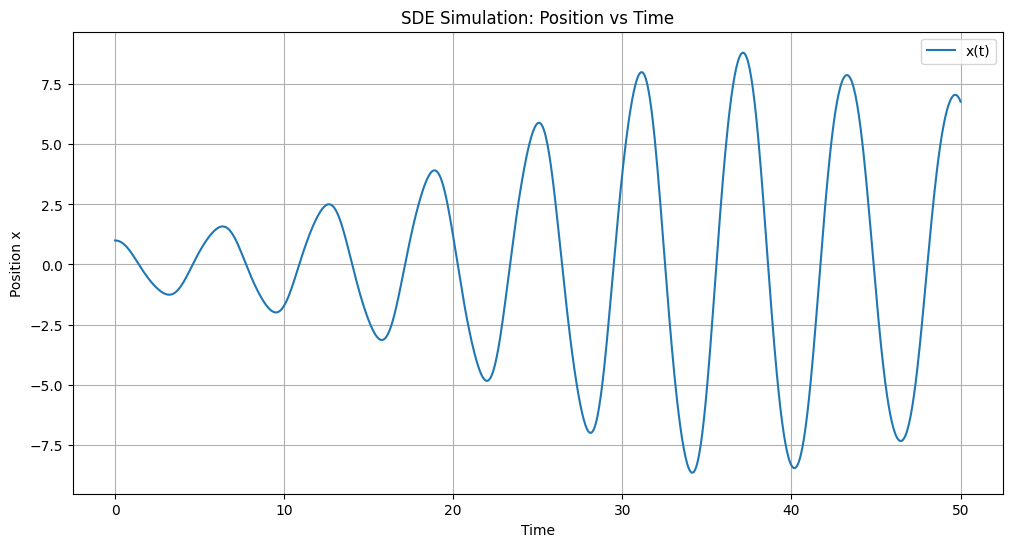

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(ts, sde_samples_x[:, 0], label='x(t)')
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title('SDE Simulation: Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

In [7]:
terms_A = MultiTerm(ODETerm(drift_A_fn), ControlTerm(diffusion_A_fn, brownian_motion))
# Define the time points for sampling
ts = jnp.linspace(t0, t1, 1000)
saveat = diffrax.SaveAt(ts=ts)
# sample 1000 points
solution_A = diffrax.diffeqsolve(
    terms_A,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=0.001,
    y0=y0,
    args=args_A,
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=100000,
)
sde_samples_A = solution_A.ys[:, :N]


100.00%|##########| [00:00<00:00, 103.90%/s]


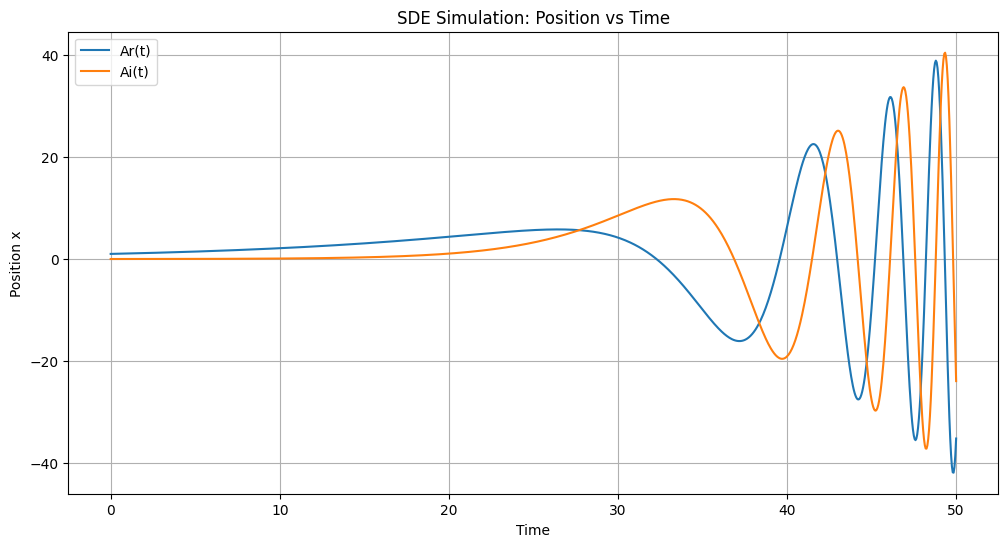

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(ts, sde_samples_A[:, 0], label='Ar(t)')
plt.plot(ts, sde_samples_A[:, 1], label='Ai(t)')
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title('SDE Simulation: Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

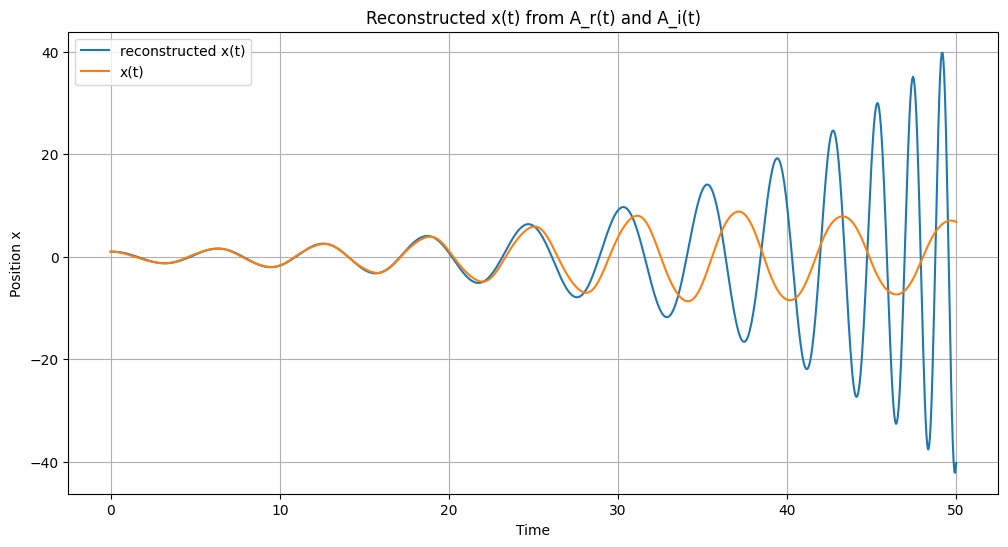

In [9]:
def reconstruct_x(t, A_r, A_i):
    """
    Reconstruct x(t) from A_r(t) and A_i(t).

    x(t) = A_r(t) * cos(omega_d t) - A_i(t) * sin(omega_d t)
    """
    return A_r * jnp.cos(omega_d * t) - A_i * jnp.sin(omega_d * t)

plt.figure(figsize=(12, 6))
plt.plot(ts, reconstruct_x(ts, sde_samples_A[:, 0], sde_samples_A[:, 1]), label='reconstructed x(t)')
plt.plot(ts, sde_samples_x[:, 0], label='x(t)')
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title('Reconstructed x(t) from A_r(t) and A_i(t)')
plt.grid(True)
plt.legend()
plt.show()